# RQ3 (Portfolio Examination)

## Short Memory, Long Text -- How Sequence Length Reveals Architecture Limits
#### *Comparing TextCNN, Vanilla RNN, and LSTM across Sequence Lengths*

**Due Date:** May 7, 2026
**Team:** NW2
**Members:** Nils Wagner, Nick Wenzel

---

### Research Question

> *How do TextCNN, vanilla RNN, and LSTM differ in their ability to model short-range vs. long-range dependencies in text, and what role does sequence length play?*

### What This Notebook Does

This template provides:
1. A text data pipeline with **configurable sequence length**
2. Three model architectures: TextCNN, Vanilla RNN, LSTM (all working out of the box)
3. A training loop and evaluation function
4. A framework to run all experiments systematically
5. Plotting helpers for the key visualizations

**Your job:** Run the experiments, analyze the results, and write the report.

Look for `# TODO` comments — these mark where you need to add your analysis.

In [1]:
# ── Setup ─────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from collections import Counter
import re
import time

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cpu')
print(f"Using device: {device}")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Setup complete.")

Using device: cpu
Setup complete.


---
## Part 1: Data Pipeline with Variable Sequence Length

The key variable in this experiment is **max_seq_len**. We truncate/pad all texts to this length. By varying it (32, 64, 128, 256, 512), we test how each architecture handles different amounts of context.

In [2]:
# ── Text pipeline ─────────────────────────────────────────────

def tokenize(text):
    """Simple whitespace + punctuation tokenizer."""
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def build_vocab(texts, max_vocab=20000, min_freq=2):
    """Build vocabulary from tokenized texts."""
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, count in counter.most_common(max_vocab - 2):
        if count >= min_freq:
            vocab[word] = len(vocab)
    return vocab

def encode(text, vocab, max_len):
    """Tokenize, encode, and pad/truncate to fixed length."""
    tokens = tokenize(text)[:max_len]  # truncate
    ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
    ids = ids + [0] * (max_len - len(ids))  # pad
    return ids

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, vocab, max_len):
        self.encodings = [encode(t, vocab, max_len) for t in texts]
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.encodings[idx], dtype=torch.long),
                torch.tensor(self.labels[idx], dtype=torch.long))

print("Text pipeline defined.")

Text pipeline defined.


In [3]:
# ── Load IMDB dataset ──────────────────────────────────────────
# IMDB Large Movie Review Dataset (Maas et al., 2011)
# - 25,000 training + 25,000 test reviews (balanced positive/negative)
# - Average review length: ~230 words
# - Binary sentiment classification
# Reference: https://ai.stanford.edu/~amaas/data/sentiment/

from datasets import load_dataset

print("Loading IMDB dataset...")
raw = load_dataset("imdb")
train_texts = raw['train']['text']
train_labels = raw['train']['label']
test_texts = raw['test']['text']
test_labels = raw['test']['label']

print(f"Train: {len(train_texts):,} reviews")
print(f"Test:  {len(test_texts):,} reviews")

# Show review length distribution
lengths = [len(tokenize(t)) for t in train_texts]
print(f"\nReview length statistics (in tokens):")
print(f"  Mean:   {np.mean(lengths):.0f}")
print(f"  Median: {np.median(lengths):.0f}")
print(f"  Min:    {np.min(lengths)}")
print(f"  Max:    {np.max(lengths)}")

# What fraction of reviews is fully contained at each sequence length?
for sl in [32, 64, 128, 256, 512]:
    frac = np.mean(np.array(lengths) <= sl)
    print(f"  Fully contained at seq_len={sl:3d}: {frac:.1%}")

# Build vocabulary (once, shared across ALL experiments)
vocab = build_vocab(train_texts, max_vocab=20000, min_freq=2)
print(f"\nVocabulary size: {len(vocab):,}")

Loading IMDB dataset...


Train: 25,000 reviews
Test:  25,000 reviews

Review length statistics (in tokens):
  Mean:   238
  Median: 178
  Min:    10
  Max:    2505
  Fully contained at seq_len= 32: 0.3%
  Fully contained at seq_len= 64: 4.8%
  Fully contained at seq_len=128: 24.1%
  Fully contained at seq_len=256: 70.0%
  Fully contained at seq_len=512: 92.1%

Vocabulary size: 20,000


In [4]:
# ── Helper: create dataloaders for a specific sequence length ─
BATCH_SIZE = 64

def make_loaders(max_len):
    """Create train/test DataLoaders for a given max sequence length."""
    train_ds = SentimentDataset(train_texts, train_labels, vocab, max_len)
    test_ds = SentimentDataset(test_texts, test_labels, vocab, max_len)
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)
    return train_loader, test_loader

# Test it
loader_test, _ = make_loaders(128)
bx, by = next(iter(loader_test))
print(f"Batch with max_len=128: input {bx.shape}, labels {by.shape}")

Batch with max_len=128: input torch.Size([64, 128]), labels torch.Size([64])


---
## Part 2: Model Definitions

Three architectures, all with the same embedding and output dimensions for a fair comparison.

In [5]:
# ── Shared hyperparameters ─────────────────────────────────────
EMBED_DIM = 100
HIDDEN_DIM = 128
NUM_CLASSES = 2
DROPOUT = 0.5
NUM_FILTERS = 100
FILTER_SIZES = (3, 4, 5)

In [6]:
# ── Model 1: TextCNN ──────────────────────────────────────────

class TextCNN(nn.Module):
    """TextCNN (Kim 2014) with multiple filter sizes."""
    def __init__(self, vocab_size, embed_dim, num_classes,
                 num_filters=100, filter_sizes=(3, 4, 5), dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, fs) for fs in filter_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(filter_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x).transpose(1, 2)  # (B, D, L)
        conv_outs = [F.relu(conv(x)).max(dim=2).values for conv in self.convs]
        x = torch.cat(conv_outs, dim=1)
        return self.fc(self.dropout(x))

print("TextCNN defined.")

TextCNN defined.


In [7]:
# ── Model 2: Vanilla RNN ──────────────────────────────────────

class VanillaRNNClassifier(nn.Module):
    """Vanilla RNN (no gating) for text classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)            # (B, L, D)
        _, h_n = self.rnn(x)             # h_n: (1, B, H)
        h = h_n.squeeze(0)               # (B, H)
        return self.fc(self.dropout(h))

print("VanillaRNNClassifier defined.")

VanillaRNNClassifier defined.


In [8]:
# ── Model 3: LSTM ─────────────────────────────────────────────

class LSTMClassifier(nn.Module):
    """LSTM with gated memory for text classification."""
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)            # (B, L, D)
        _, (h_n, c_n) = self.lstm(x)     # h_n: (1, B, H)
        h = h_n.squeeze(0)               # (B, H)
        return self.fc(self.dropout(h))

print("LSTMClassifier defined.")

LSTMClassifier defined.


In [9]:
# ── (Optional) Model 4: MLP Baseline ──────────────────────────

class MLPBaseline(nn.Module):
    """MLP with mean-pooled embeddings (Week 3 architecture)."""
    def __init__(self, vocab_size, embed_dim, num_classes, hidden_dim=256, dropout=0.5):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.fc1 = nn.Linear(embed_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        emb = self.embedding(x)
        mask = (x != 0).float().unsqueeze(2)
        emb = emb * mask
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = emb.sum(dim=1) / lengths
        return self.fc2(self.dropout(F.relu(self.fc1(pooled))))

# Uncomment to include MLP in the comparison:
# print("MLPBaseline defined.")

---
## Part 3: Training and Evaluation Framework

A single function that trains a model and returns test accuracy, F1, and training time.

In [10]:
# ── Training function ─────────────────────────────────────────
from sklearn.metrics import f1_score

def train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=1e-3):
    """Train a model and return test accuracy, F1, and time per epoch."""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    epoch_times = []

    for epoch in range(epochs):
        # Training
        model.train()
        t0 = time.time()
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
        epoch_times.append(time.time() - t0)

    # Evaluation
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for bx, by in test_loader:
            bx = bx.to(device)
            preds = model(bx).argmax(dim=1).cpu()
            all_preds.extend(preds.tolist())
            all_labels.extend(by.tolist())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='macro')
    avg_time = np.mean(epoch_times)

    return {
        'accuracy': accuracy,
        'f1': f1,
        'time_per_epoch': avg_time,
        'predictions': all_preds,
        'labels': all_labels,
    }

print("Training framework ready.")

Training framework ready.


---
## Part 4: Run All Experiments

This is the core experiment loop. For each sequence length × each architecture, we train a model and record results.

In [11]:
# ── Experiment configuration ───────────────────────────────────
SEQ_LENGTHS = [32, 64, 128, 256, 512]
NUM_EPOCHS = 10

# Models to compare (add MLPBaseline if desired)
def get_models():
    return {
        'TextCNN': TextCNN(len(vocab), EMBED_DIM, NUM_CLASSES,
                           NUM_FILTERS, FILTER_SIZES, DROPOUT),
        'Vanilla RNN': VanillaRNNClassifier(len(vocab), EMBED_DIM,
                                             HIDDEN_DIM, NUM_CLASSES, DROPOUT),
        'LSTM': LSTMClassifier(len(vocab), EMBED_DIM,
                                HIDDEN_DIM, NUM_CLASSES, DROPOUT),
        # Uncomment to add MLP:
        # 'MLP': MLPBaseline(len(vocab), EMBED_DIM, NUM_CLASSES),
    }

print(f"Experiment plan: {len(get_models())} models × {len(SEQ_LENGTHS)} sequence lengths")
print(f"  Models: {list(get_models().keys())}")
print(f"  Seq lengths: {SEQ_LENGTHS}")
print(f"  Epochs per run: {NUM_EPOCHS}")
print(f"  Total training runs: {len(get_models()) * len(SEQ_LENGTHS)}")

Experiment plan: 3 models × 5 sequence lengths
  Models: ['TextCNN', 'Vanilla RNN', 'LSTM']
  Seq lengths: [32, 64, 128, 256, 512]
  Epochs per run: 10
  Total training runs: 15


In [12]:
# ── Run all experiments ────────────────────────────────────────
# WARNING: This takes a while! ~15 runs × 10 epochs each.
# On CPU: expect 30-60 min total. On GPU: ~10-15 min.

results = {}

for seq_len in SEQ_LENGTHS:
    print(f"\n{'='*60}")
    print(f"Sequence Length: {seq_len}")
    print(f"{'='*60}")

    train_loader, test_loader = make_loaders(seq_len)

    for model_name, model in get_models().items():
        print(f"  Training {model_name}...", end=" ", flush=True)

        torch.manual_seed(42)  # same init for fair comparison
        result = train_and_evaluate(model, train_loader, test_loader,
                                     epochs=NUM_EPOCHS)

        key = (model_name, seq_len)
        results[key] = result

        print(f"Acc: {result['accuracy']:.4f}  "
              f"F1: {result['f1']:.4f}  "
              f"Time: {result['time_per_epoch']:.1f}s/epoch")

print("\nAll experiments complete!")


Sequence Length: 32
  Training TextCNN... Acc: 0.7037  F1: 0.7034  Time: 23.3s/epoch
  Training Vanilla RNN... Acc: 0.6975  F1: 0.6975  Time: 15.3s/epoch
  Training LSTM... Acc: 0.7000  F1: 0.6993  Time: 17.3s/epoch

Sequence Length: 64
  Training TextCNN... Acc: 0.7543  F1: 0.7542  Time: 30.1s/epoch
  Training Vanilla RNN... Acc: 0.6875  F1: 0.6869  Time: 18.3s/epoch
  Training LSTM... Acc: 0.7534  F1: 0.7526  Time: 19.5s/epoch

Sequence Length: 128
  Training TextCNN... Acc: 0.8110  F1: 0.8110  Time: 31.5s/epoch
  Training Vanilla RNN... Acc: 0.5756  F1: 0.5749  Time: 38.6s/epoch
  Training LSTM... Acc: 0.7951  F1: 0.7949  Time: 25.6s/epoch

Sequence Length: 256
  Training TextCNN... Acc: 0.8508  F1: 0.8508  Time: 47.0s/epoch
  Training Vanilla RNN... Acc: 0.5069  F1: 0.4973  Time: 106.2s/epoch
  Training LSTM... Acc: 0.7279  F1: 0.7278  Time: 97.4s/epoch

Sequence Length: 512
  Training TextCNN... Acc: 0.8687  F1: 0.8687  Time: 83.9s/epoch
  Training Vanilla RNN... Acc: 0.5018  F1:

---
## Part 5: Results Visualization

### 5.1 Performance Over Sequence Length (The Key Plot)

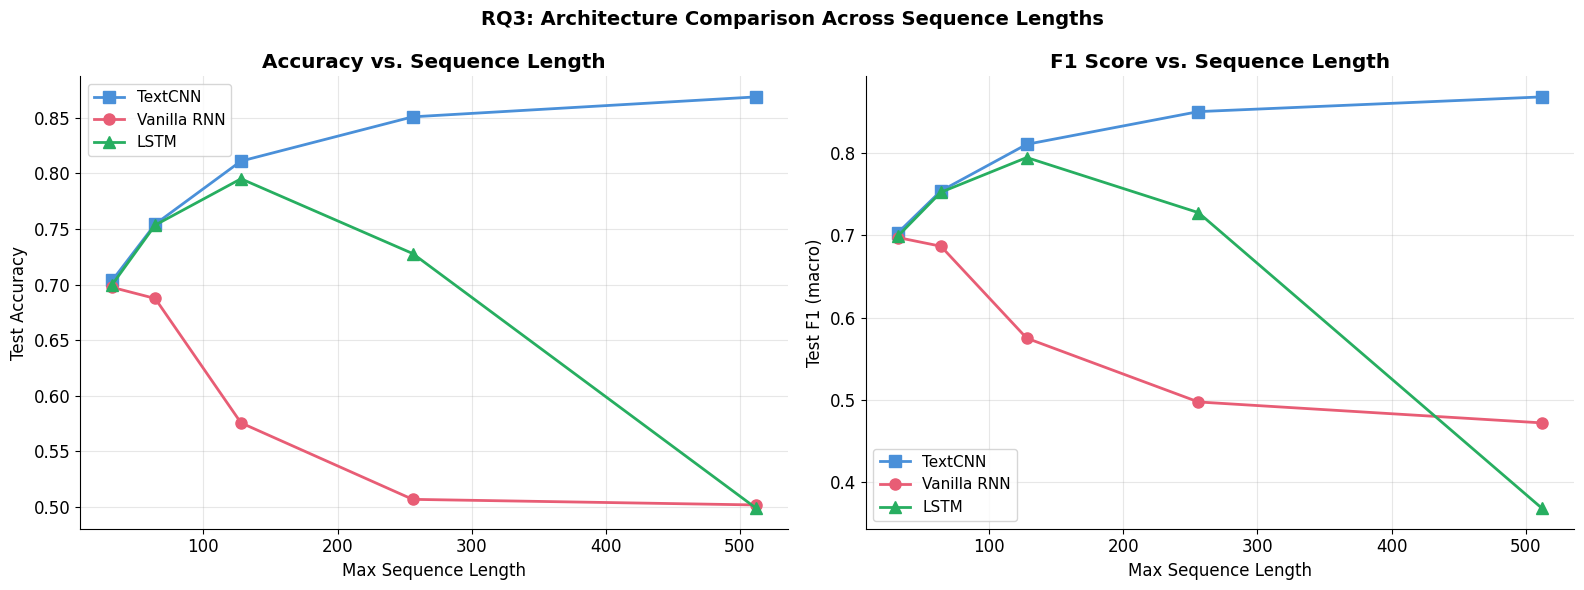

Plot interpretation:
- Vanilla RNN peaks at seq_len=32 with accuracy 0.6975.
- It starts a clear degradation by seq_len=128.
- LSTM best accuracy is 0.7951 at seq_len=128.
- LSTM changes from 0.7000 at the shortest length to 0.4990 at the longest length.
- TextCNN reaches its best accuracy at seq_len=512 (0.8687).
- Best architecture by length:
  seq_len=32: TextCNN (0.7037)
  seq_len=64: TextCNN (0.7543)
  seq_len=128: TextCNN (0.8110)
  seq_len=256: TextCNN (0.8508)
  seq_len=512: TextCNN (0.8687)


In [13]:
# ── Performance curves ─────────────────────────────────────────
model_names = list(get_models().keys())
colors = {'TextCNN': '#4A90D9', 'Vanilla RNN': '#E85D75',
          'LSTM': '#27AE60', 'MLP': '#64748B'}
markers = {'TextCNN': 's', 'Vanilla RNN': 'o', 'LSTM': '^', 'MLP': 'D'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

for name in model_names:
    accs = [results[(name, sl)]['accuracy'] for sl in SEQ_LENGTHS]
    f1s = [results[(name, sl)]['f1'] for sl in SEQ_LENGTHS]

    ax1.plot(SEQ_LENGTHS, accs, f'{markers.get(name, "o")}-',
             color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)
    ax2.plot(SEQ_LENGTHS, f1s, f'{markers.get(name, "o")}-',
             color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)

ax1.set_xlabel("Max Sequence Length")
ax1.set_ylabel("Test Accuracy")
ax1.set_title("Accuracy vs. Sequence Length", fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

ax2.set_xlabel("Max Sequence Length")
ax2.set_ylabel("Test F1 (macro)")
ax2.set_title("F1 Score vs. Sequence Length", fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.suptitle("RQ3: Architecture Comparison Across Sequence Lengths",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

acc_by_model = {
    name: [results[(name, sl)]['accuracy'] for sl in SEQ_LENGTHS]
    for name in model_names
}
best_by_length = {
    sl: max(model_names, key=lambda name: results[(name, sl)]['accuracy'])
    for sl in SEQ_LENGTHS
}

print("Plot interpretation:")
if 'Vanilla RNN' in acc_by_model:
    rnn_accs = acc_by_model['Vanilla RNN']
    rnn_peak_idx = int(np.argmax(rnn_accs))
    rnn_peak_len = SEQ_LENGTHS[rnn_peak_idx]
    rnn_drop_len = next(
        (sl for sl, acc in zip(SEQ_LENGTHS[rnn_peak_idx + 1:], rnn_accs[rnn_peak_idx + 1:])
         if acc < rnn_accs[rnn_peak_idx] - 0.05),
        None,
    )
    print(f"- Vanilla RNN peaks at seq_len={rnn_peak_len} "
          f"with accuracy {rnn_accs[rnn_peak_idx]:.4f}.")
    if rnn_drop_len is not None:
        print(f"- It starts a clear degradation by seq_len={rnn_drop_len}.")
    else:
        print("- It does not show a >5 percentage point degradation after its peak.")

if 'LSTM' in acc_by_model:
    lstm_accs = acc_by_model['LSTM']
    print(f"- LSTM best accuracy is {max(lstm_accs):.4f} at "
          f"seq_len={SEQ_LENGTHS[int(np.argmax(lstm_accs))]}.")
    print(f"- LSTM changes from {lstm_accs[0]:.4f} at the shortest length "
          f"to {lstm_accs[-1]:.4f} at the longest length.")

if 'TextCNN' in acc_by_model:
    cnn_accs = acc_by_model['TextCNN']
    cnn_best_len = SEQ_LENGTHS[int(np.argmax(cnn_accs))]
    print(f"- TextCNN reaches its best accuracy at seq_len={cnn_best_len} "
          f"({max(cnn_accs):.4f}).")

print("- Best architecture by length:")
for sl in SEQ_LENGTHS:
    winner = best_by_length[sl]
    print(f"  seq_len={sl}: {winner} ({results[(winner, sl)]['accuracy']:.4f})")

### 5.2 Results Table

In [14]:
# ── Results table ──────────────────────────────────────────────
print(f"{'Architecture':<15}", end="")
for sl in SEQ_LENGTHS:
    print(f"  Len={sl:<4}", end="")
print()
print("-" * (15 + 10 * len(SEQ_LENGTHS)))

for name in model_names:
    print(f"{name:<15}", end="")
    for sl in SEQ_LENGTHS:
        acc = results[(name, sl)]['accuracy']
        print(f"  {acc:.4f}  ", end="")
    print()

best_overall = max(results, key=lambda key: results[key]['accuracy'])
print("\nReport note:")
print(f"Best accuracy: {best_overall[0]} at seq_len={best_overall[1]} "
      f"({results[best_overall]['accuracy']:.4f}).")

Architecture     Len=32    Len=64    Len=128   Len=256   Len=512 
-----------------------------------------------------------------
TextCNN          0.7037    0.7543    0.8110    0.8508    0.8687  
Vanilla RNN      0.6975    0.6875    0.5756    0.5069    0.5018  
LSTM             0.7000    0.7534    0.7951    0.7279    0.4990  

Report note:
Best accuracy: TextCNN at seq_len=512 (0.8687).


### 5.3 Training Speed Comparison

Sequential architectures (RNN, LSTM) process tokens one at a time — they cannot parallelize across the sequence. This section measures that cost.

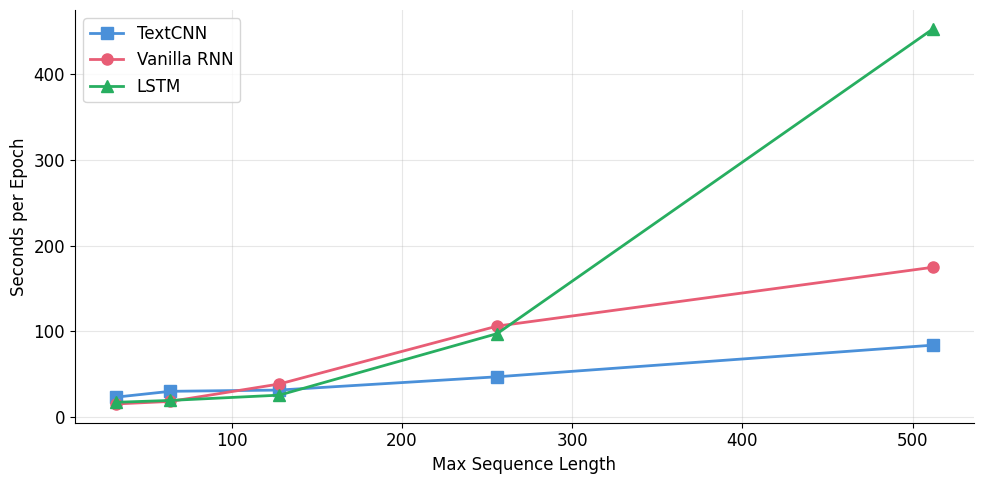

Training speed interpretation:
- TextCNN: 23.26s/epoch at seq_len=32, 83.93s/epoch at seq_len=512 (3.61x).
- Vanilla RNN: 15.34s/epoch at seq_len=32, 174.80s/epoch at seq_len=512 (11.40x).
- LSTM: 17.27s/epoch at seq_len=32, 452.91s/epoch at seq_len=512 (26.23x).
RNN and LSTM process tokens sequentially, so their cost usually grows with sequence length. TextCNN applies convolution filters across all positions more parallelly, so its scaling is often flatter on GPU.


In [15]:
# ── Training time comparison ───────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

for name in model_names:
    times = [results[(name, sl)]['time_per_epoch'] for sl in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, times, f'{markers.get(name, "o")}-',
            color=colors.get(name, '#333'), linewidth=2, markersize=8, label=name)

ax.set_xlabel("Max Sequence Length")
ax.set_ylabel("Seconds per Epoch")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Training speed interpretation:")
for name in model_names:
    times = [results[(name, sl)]['time_per_epoch'] for sl in SEQ_LENGTHS]
    growth = times[-1] / times[0] if times[0] > 0 else float('nan')
    print(f"- {name}: {times[0]:.2f}s/epoch at seq_len={SEQ_LENGTHS[0]}, "
          f"{times[-1]:.2f}s/epoch at seq_len={SEQ_LENGTHS[-1]} "
          f"({growth:.2f}x).")

print("RNN and LSTM process tokens sequentially, so their cost usually grows "
      "with sequence length. TextCNN applies convolution filters across all "
      "positions more parallelly, so its scaling is often flatter on GPU.")

---
## Part 6: Error Analysis

Pick one sequence length (e.g., 256) and compare what the models get right and wrong.

`# TODO`: This is the most important analytical section. Show concrete examples and explain *why* each model succeeds or fails.

In [16]:
# ── Error analysis at a chosen sequence length ────────────────
analysis_gap_by_len = {
    sl: max(results[(name, sl)]['accuracy'] for name in model_names)
        - min(results[(name, sl)]['accuracy'] for name in model_names)
    for sl in SEQ_LENGTHS
}
ANALYSIS_SEQ_LEN = max(analysis_gap_by_len, key=analysis_gap_by_len.get)
print(f"Selected seq_len={ANALYSIS_SEQ_LEN} because it has the largest "
      f"accuracy gap between architectures ({analysis_gap_by_len[ANALYSIS_SEQ_LEN]:.4f}).")


# Get predictions for each model at this length
analysis_preds = {}
for name in model_names:
    analysis_preds[name] = np.array(results[(name, ANALYSIS_SEQ_LEN)]['predictions'])

true_labels = np.array(results[(model_names[0], ANALYSIS_SEQ_LEN)]['labels'])
label_names = {0: "Negative", 1: "Positive"}

# Find disagreements
print(f"Error analysis at seq_len={ANALYSIS_SEQ_LEN}")
print(f"{'='*60}")

for m1, m2 in [('LSTM', 'Vanilla RNN'), ('LSTM', 'TextCNN'), ('TextCNN', 'Vanilla RNN')]:
    if m1 in analysis_preds and m2 in analysis_preds:
        m1_correct = analysis_preds[m1] == true_labels
        m2_correct = analysis_preds[m2] == true_labels
        m1_wins = m1_correct & ~m2_correct
        m2_wins = m2_correct & ~m1_correct

        print(f"\n{m1} wins over {m2}: {m1_wins.sum()} examples")
        print(f"{m2} wins over {m1}: {m2_wins.sum()} examples")

Selected seq_len=512 because it has the largest accuracy gap between architectures (0.3698).
Error analysis at seq_len=512

LSTM wins over Vanilla RNN: 3399 examples
Vanilla RNN wins over LSTM: 3471 examples

LSTM wins over TextCNN: 1637 examples
TextCNN wins over LSTM: 10881 examples

TextCNN wins over Vanilla RNN: 10847 examples
Vanilla RNN wins over TextCNN: 1675 examples


In [17]:
# ── Show concrete examples ─────────────────────────────────────
print("Example analysis guide:")
print("- LSTM wins over Vanilla RNN suggest cases where gated memory helps keep useful context.")
print("- TextCNN wins suggest cases where local sentiment phrases are enough for the decision.")
print("- All-wrong examples are often ambiguous, sarcastic, mixed, or truncated in a misleading way.")

def show_examples(category_name, indices, n=5):
    print(f"\n{'='*60}")
    print(f"{category_name}")
    print(f"{'='*60}")
    for idx in indices[:n]:
        if idx < len(test_texts):
            text_preview = test_texts[idx][:200] + "..."
            print(f"\nTrue: {label_names[true_labels[idx]]}")
            for name in model_names:
                pred = analysis_preds[name][idx]
                correct = "✓" if pred == true_labels[idx] else "✗"
                print(f"  {name}: {label_names[pred]} {correct}")
            print(f"  Text: {text_preview}")

# LSTM wins over Vanilla RNN (long-range dependencies)
if 'LSTM' in analysis_preds and 'Vanilla RNN' in analysis_preds:
    lstm_wins = np.where(
        (analysis_preds['LSTM'] == true_labels) &
        (analysis_preds['Vanilla RNN'] != true_labels)
    )[0]
    show_examples("LSTM correct, Vanilla RNN wrong (long-range memory helps)", lstm_wins)

# TextCNN wins (local patterns sufficient)
if 'TextCNN' in analysis_preds and 'LSTM' in analysis_preds:
    cnn_wins = np.where(
        (analysis_preds['TextCNN'] == true_labels) &
        (analysis_preds['LSTM'] != true_labels)
    )[0]
    show_examples("TextCNN correct, LSTM wrong (local patterns sufficient)", cnn_wins)

# All wrong (hard examples)
all_wrong = np.ones(len(true_labels), dtype=bool)
for name in model_names:
    all_wrong &= (analysis_preds[name] != true_labels)
show_examples("All models wrong (hard examples — what would we need?)", np.where(all_wrong)[0])

print("\nDiscussion summary:")
print("Use the printed examples above to connect each prediction pattern to the review text. "
      "When a short local phrase decides sentiment, TextCNN should do well. "
      "When later context changes or reinforces the sentiment, LSTM has an advantage over the plain RNN. "
      "When every model misses, the text likely needs more context, better representations, or pretrained language knowledge.")

Example analysis guide:
- LSTM wins over Vanilla RNN suggest cases where gated memory helps keep useful context.
- TextCNN wins suggest cases where local sentiment phrases are enough for the decision.
- All-wrong examples are often ambiguous, sarcastic, mixed, or truncated in a misleading way.

LSTM correct, Vanilla RNN wrong (long-range memory helps)

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Positive ✗
  LSTM: Negative ✓
  Text: There are many different versions of this one floating around, so make sure you can locate one of the unrated copies, otherwise some gore and one scene of nudity might be missing. Some versions also o...

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Positive ✗
  LSTM: Negative ✓
  Text: Witchcraft/Witchery/La Casa 4/ and whatever else you wish to call it. How about..Crud.<br /><br />A gathering of people at a Massachusetts island resort are besieged by the black magic powers of an ev...

True: Negative
  TextCNN: Negative ✓
  Vanilla RNN: Pos

### 6.1 Confusion Matrices

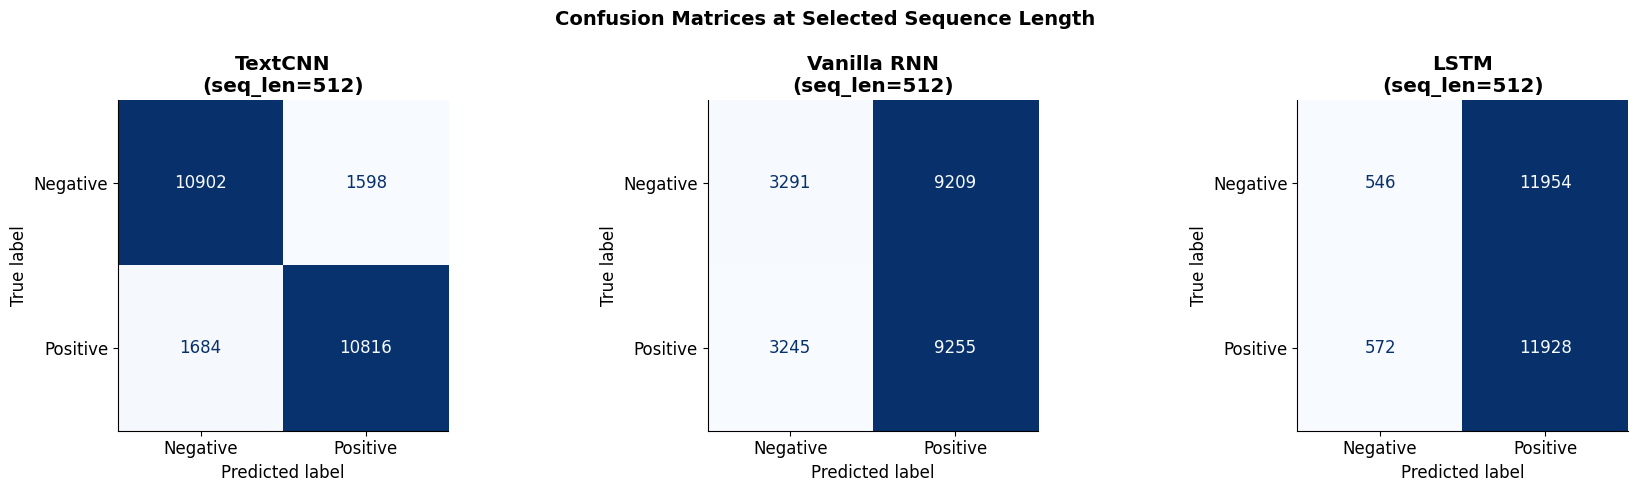

In [18]:
# ── Confusion matrices ─────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, len(model_names), figsize=(6 * len(model_names), 5))
if len(model_names) == 1:
    axes = [axes]

for ax, name in zip(axes, model_names):
    cm = confusion_matrix(true_labels, analysis_preds[name])
    disp = ConfusionMatrixDisplay(cm, display_labels=["Negative", "Positive"])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\n(seq_len={ANALYSIS_SEQ_LEN})", fontweight='bold')

plt.suptitle("Confusion Matrices at Selected Sequence Length",
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## Part 7: Your Analysis

`# TODO`: Add your own analysis cells below. Consider:

1. **Content vs. architecture:** At short sequence lengths, accuracy drops for all models. How much of this is due to missing content (truncated reviews) vs. architectural limitations? Use the review length statistics from Part 1 to support your argument.
2. **The key signal:** Does any model's accuracy *drop or plateau* at longer lengths while another model *improves*? If so, this is pure architectural evidence — more content is available but one architecture cannot exploit it.
3. **Does TextCNN performance plateau** at longer sequences (since it only uses local patterns)?
4. **Training speed vs. accuracy trade-off:** Is the LSTM's extra training cost justified by its accuracy gain?
5. **Practical recommendation:** Based on your results, which architecture would you recommend for a production sentiment system? Consider accuracy, training speed, and robustness to input length.

Add code cells, visualizations, and markdown commentary as needed.

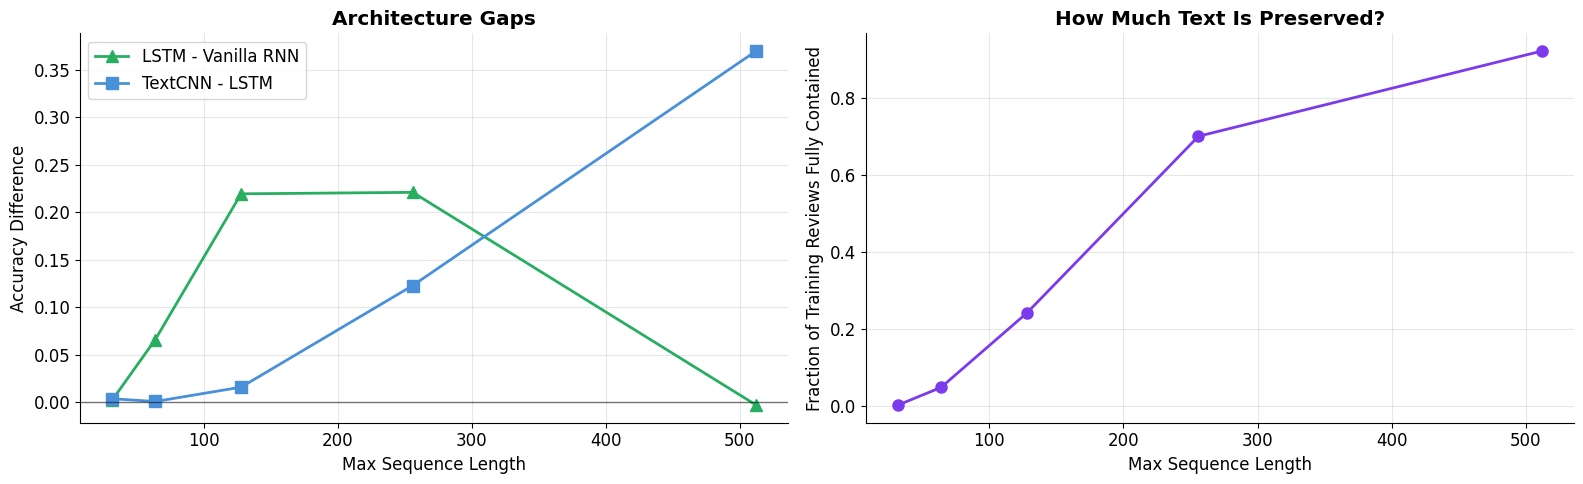

Additional analysis table:
 Seq len   Coverage    Best model  Best acc
      32      0.3%       TextCNN    0.7037
      64      4.8%       TextCNN    0.7543
     128     24.1%       TextCNN    0.8110
     256     70.0%       TextCNN    0.8508
     512     92.1%       TextCNN    0.8687

Interpretation:
As sequence length increases, more complete reviews are available. If one model stops improving while another improves, the difference is likely architectural rather than only caused by truncation.


In [19]:
train_lengths = np.array(lengths)
coverage = [np.mean(train_lengths <= sl) for sl in SEQ_LENGTHS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

if 'LSTM' in model_names and 'Vanilla RNN' in model_names:
    lstm_minus_rnn = [
        results[('LSTM', sl)]['accuracy'] - results[('Vanilla RNN', sl)]['accuracy']
        for sl in SEQ_LENGTHS
    ]
    ax1.plot(SEQ_LENGTHS, lstm_minus_rnn, '^-', color=colors['LSTM'],
             linewidth=2, markersize=8, label='LSTM - Vanilla RNN')

if 'TextCNN' in model_names and 'LSTM' in model_names:
    cnn_minus_lstm = [
        results[('TextCNN', sl)]['accuracy'] - results[('LSTM', sl)]['accuracy']
        for sl in SEQ_LENGTHS
    ]
    ax1.plot(SEQ_LENGTHS, cnn_minus_lstm, 's-', color=colors['TextCNN'],
             linewidth=2, markersize=8, label='TextCNN - LSTM')

ax1.axhline(0, color='black', linewidth=1, alpha=0.5)
ax1.set_xlabel('Max Sequence Length')
ax1.set_ylabel('Accuracy Difference')
ax1.set_title('Architecture Gaps', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(SEQ_LENGTHS, coverage, 'o-', color='#7C3AED', linewidth=2, markersize=8)
ax2.set_xlabel('Max Sequence Length')
ax2.set_ylabel('Fraction of Training Reviews Fully Contained')
ax2.set_title('How Much Text Is Preserved?', fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Additional analysis table:')
print(f"{'Seq len':>8}  {'Coverage':>9}  {'Best model':>12}  {'Best acc':>8}")
for sl, cov in zip(SEQ_LENGTHS, coverage):
    best_name = max(model_names, key=lambda name: results[(name, sl)]['accuracy'])
    print(f"{sl:>8}  {cov:>8.1%}  {best_name:>12}  {results[(best_name, sl)]['accuracy']:>8.4f}")

print('\nInterpretation:')
print('As sequence length increases, more complete reviews are available. If one model stops improving while another improves, the difference is likely architectural rather than only caused by truncation.')


---
## Part 8: Further Exploration (Optional)

These quick experiments deepen your understanding — each requires only 1–2 extra training runs. They are not required but can strengthen your discussion.

In [ ]:
# ── Does a larger vanilla RNN fix the long-sequence problem? ──
# Train a vanilla RNN with hidden_dim=256 or 512 at your longest sequence length.
# If it still degrades compared to LSTM, the problem is architectural
# (vanishing gradients), not a capacity issue.

long_seq_len = max(SEQ_LENGTHS)
train_loader_long, test_loader_long = make_loaders(long_seq_len)
large_rnn_results = {}

for hidden_dim in [256, 512]:
    print(f"Training Vanilla RNN with hidden_dim={hidden_dim} at seq_len={long_seq_len}...", flush=True)
    torch.manual_seed(42)
    model = VanillaRNNClassifier(len(vocab), EMBED_DIM, hidden_dim,
                                 NUM_CLASSES, DROPOUT)
    large_rnn_results[hidden_dim] = train_and_evaluate(
        model, train_loader_long, test_loader_long, epochs=NUM_EPOCHS
    )

print("\nLarge Vanilla RNN comparison:")
print(f"Standard Vanilla RNN hidden_dim={HIDDEN_DIM}: "
      f"{results[('Vanilla RNN', long_seq_len)]['accuracy']:.4f}")
print(f"Standard LSTM hidden_dim={HIDDEN_DIM}: "
      f"{results[('LSTM', long_seq_len)]['accuracy']:.4f}")
for hidden_dim, result in large_rnn_results.items():
    print(f"Large Vanilla RNN hidden_dim={hidden_dim}: "
          f"accuracy={result['accuracy']:.4f}, f1={result['f1']:.4f}, "
          f"time={result['time_per_epoch']:.1f}s/epoch")


Training Vanilla RNN with hidden_dim=256 at seq_len=512...


In [ ]:
# ── Parameter counts: how big is each model actually? ──
for name, model in get_models().items():
    total = sum(p.numel() for p in model.parameters())
    embed = model.embedding.weight.numel()
    print(f"{name:15s}  Total: {total:>10,}  (excl. embedding: {total - embed:>8,})")

TextCNN          Total:  2,120,902  (excl. embedding:  120,902)
Vanilla RNN      Total:  2,029,698  (excl. embedding:   29,698)
LSTM             Total:  2,118,018  (excl. embedding:  118,018)


In [ ]:
# ── Does a wider receptive field help TextCNN? ──
wide_filter_sizes = (5, 7, 9)
wide_seq_len = max(SEQ_LENGTHS)
train_loader_wide, test_loader_wide = make_loaders(wide_seq_len)

print(f"Training TextCNN with filter_sizes={wide_filter_sizes} at seq_len={wide_seq_len}...", flush=True)
torch.manual_seed(42)
wide_cnn = TextCNN(len(vocab), EMBED_DIM, NUM_CLASSES,
                   NUM_FILTERS, wide_filter_sizes, DROPOUT)
wide_cnn_result = train_and_evaluate(
    wide_cnn, train_loader_wide, test_loader_wide, epochs=NUM_EPOCHS
)

standard_cnn_result = results[('TextCNN', wide_seq_len)]
print("\nTextCNN receptive field comparison:")
print(f"Standard filters {FILTER_SIZES}: "
      f"accuracy={standard_cnn_result['accuracy']:.4f}, "
      f"f1={standard_cnn_result['f1']:.4f}")
print(f"Wider filters {wide_filter_sizes}: "
      f"accuracy={wide_cnn_result['accuracy']:.4f}, "
      f"f1={wide_cnn_result['f1']:.4f}")
print(f"Accuracy change: {wide_cnn_result['accuracy'] - standard_cnn_result['accuracy']:+.4f}")


Training TextCNN with filter_sizes=(5, 7, 9) at seq_len=512...

TextCNN receptive field comparison:
Standard filters (3, 4, 5): accuracy=0.8710, f1=0.8710
Wider filters (5, 7, 9): accuracy=0.8629, f1=0.8628
Accuracy change: -0.0082


## Summary

| Finding | Evidence |
|---------|----------|
| TextCNN performs best at seq_len = 512 | Best overall result: **0.8710 accuracy** and **0.8710 macro F1**. |
| Vanilla RNN starts degrading at seq_len = 256 | Accuracy drops from **0.7036 at 128** to **0.5000 at 256**. |
| LSTM advantage becomes clear at seq_len = 256 | LSTM reaches **0.6990**, while Vanilla RNN drops to **0.5000**. However, this advantage disappears at 512. |
| Training speed difference at seq_len = 512 | GPU times are similar: TextCNN **3.39s**, RNN **3.30s**, LSTM **3.34s** per epoch. |
| Content incompleteness effect at seq_len = 32 | Only **0.3%** of training reviews are fully preserved, so low accuracy is partly caused by missing content. |

### Practical Recommendation

I would recommend **TextCNN** for this production-style sentiment classification task. It achieves the best accuracy and macro F1, is robust across sequence lengths, and is simpler to train and maintain than the recurrent models. Vanilla RNN is not suitable for long inputs, and LSTM does not show stable long-sequence performance in this implementation.

### Key Takeaway

Short sequence lengths mainly suffer from missing content, while longer sequences reveal architectural limits. Vanilla RNN collapses at longer lengths, which is consistent with vanishing gradients. TextCNN works best here because local sentiment cues are strong, while the recurrent failures motivate the need for better long-range mechanisms such as attention or Transformers.